# Part 4 — Iterative LQR (iLQR)

We implement the iterative LQR algorithm to perform acrobatic maneuvers with the 2D quadrotor.

## Task 1 — Reaching a vertical orientation
Reach θ = π/2 at position (x=3, y=3) at t=5, then return to the origin at T=10.  
Initial state: z₀ = 0 (hovering at origin).

## Task 2 — Full flip
Reach upside-down state (x=1.5, y=3, θ=π) at t=5, then complete the flip to (x=3, y=0, θ=2π) at T=10.

In [38]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sympy.utilities.lambdify import lambdify
import warnings
import quadrotor

warnings.filterwarnings('ignore')

dt      = quadrotor.DELTA_T
mass    = quadrotor.MASS
Len     = quadrotor.LENGTH
Inertia = quadrotor.INERTIA
grav    = quadrotor.GRAVITY
u_star  = np.array([mass * grav / 2, mass * grav / 2])  # hover control

def save_plt(title, flag=True):
    if flag:
        plt.savefig(f'data_viz/{title}-Task4.png', dpi=150, bbox_inches='tight')

def save_animate(title, animate_object, flag=True):
    my_anim, fps = animate_object
    if flag:
        my_anim.save(f'data_viz/{title}-Task4.mp4', writer='ffmpeg', fps=fps, dpi=200)
        my_anim.save(f'data_viz/{title}-Task4.gif', writer='pillow', fps=fps, dpi=100)

print(f'm={mass}, r={Len}, I={Inertia}, g={grav}, dt={dt}')
print(f'u* (hover) = {u_star}')

m=0.6, r=0.2, I=0.15, g=9.81, dt=0.01
u* (hover) = [2.943 2.943]


## Symbolic Linearization
Reused from Part 3 — computes Jacobians A and B of the discrete dynamics at any (z, u).

In [39]:
x_s, V_x_s, y_s, V_y_s, theta_s, omega_s, u1_s, u2_s = sym.symbols(
    'x V_x y V_y theta omega u1 u2')

def build_linearization():
    z_sym = sym.Matrix([[x_s],[V_x_s],[y_s],[V_y_s],[theta_s],[omega_s]])
    u_sym = sym.Matrix([[u1_s],[u2_s]])

    A_ps = sym.Matrix([[V_x_s],[0],[V_y_s],[-grav],[omega_s],[0]])
    B_ps = sym.Matrix([
        [0],
        [(-sym.sin(theta_s) / mass) * (u1_s + u2_s)],
        [0],
        [(sym.cos(theta_s) / mass) * (u1_s + u2_s)],
        [0],
        [(Len / Inertia) * (u1_s - u2_s)]
    ])
    dzdt  = (A_ps + B_ps).T
    z_next = z_sym.T + dt * dzdt

    A_sym = z_next.jacobian(z_sym)
    B_sym = z_next.jacobian(u_sym)

    A_func = lambdify((x_s,V_x_s,y_s,V_y_s,theta_s,omega_s,u1_s,u2_s), A_sym, 'numpy')
    B_func = lambdify((x_s,V_x_s,y_s,V_y_s,theta_s,omega_s,u1_s,u2_s), B_sym, 'numpy')
    return A_func, B_func

A_func, B_func = build_linearization()
print("Linearization ready.")

def get_AB(z_n, u_n):
    """Evaluate A and B matrices at a given state and control."""
    A_n = np.array(A_func(*z_n, *u_n), dtype=float)
    B_n = np.array(B_func(*z_n, *u_n), dtype=float)
    return A_n, B_n

def forward_simulate(z0, u_traj, N):
    """Roll out dynamics given a control trajectory."""
    z_traj = np.zeros((6, N + 1))
    z_traj[:, 0] = z0
    for n in range(N):
        z_traj[:, n + 1] = quadrotor.get_next_state(z_traj[:, n], u_traj[:, n])
    return z_traj

Linearization ready.


## iLQR Core — Backward and Forward Passes
Generic implementation reused for both tasks.

In [40]:
def ilqr_backward(z_traj, u_traj, l_z, l_u, l_zz, l_uu, l_uz, l_z_N, l_zz_N, N):
    """Backward pass: compute feedback gains K and feedforward k at each step."""
    K_list, k_list = [], []
    V_zz = l_zz_N.copy()
    V_z  = l_z_N.copy()

    for n in range(N - 1, -1, -1):
        A_n, B_n = get_AB(z_traj[:, n], u_traj[:, n])

        Q_zz = l_zz[n] + A_n.T @ V_zz @ A_n
        Q_uu = l_uu[n] + B_n.T @ V_zz @ B_n
        Q_uz = l_uz[n] + B_n.T @ V_zz @ A_n
        Q_z  = l_z[n]  + A_n.T @ V_z
        Q_u  = l_u[n]  + B_n.T @ V_z

        Q_uu_inv = np.linalg.inv(Q_uu)
        K_n = -Q_uu_inv @ Q_uz
        k_n = -Q_uu_inv @ Q_u

        V_zz = Q_zz - K_n.T @ Q_uu @ K_n
        V_z  = Q_z  - K_n.T @ Q_uu @ k_n

        K_list.insert(0, K_n)
        k_list.insert(0, k_n)

    return K_list, k_list


def ilqr_forward(z_traj, u_traj, K_list, k_list, alpha, z0, N):
    """Forward pass with step size alpha."""
    z_new = np.zeros_like(z_traj)
    u_new = np.zeros_like(u_traj)
    z_new[:, 0] = z0
    for n in range(N):
        dz = z_new[:, n] - z_traj[:, n]
        u_new[:, n] = u_traj[:, n] + alpha * k_list[n] + K_list[n] @ dz
        z_new[:, n + 1] = quadrotor.get_next_state(z_new[:, n], u_new[:, n])
    return z_new, u_new


def run_ilqr(z0, N, compute_cost_fn, get_approx_fn, max_iter=30):
    """Main iLQR loop with line search."""
    u_traj = np.tile(u_star, (N, 1)).T   # initialise with hover control
    z_traj = forward_simulate(z0, u_traj, N)
    cost   = compute_cost_fn(z_traj, u_traj)
    print(f'Initial cost: {cost:.2f}')

    cost_history = [cost]
    for it in range(max_iter):
        args = get_approx_fn(z_traj, u_traj)
        K_list, k_list = ilqr_backward(z_traj, u_traj, *args, N)

        alpha, improved = 1.0, False
        while alpha >= 0.01:
            z_new, u_new = ilqr_forward(z_traj, u_traj, K_list, k_list, alpha, z0, N)
            new_cost = compute_cost_fn(z_new, u_new)
            if new_cost < cost:
                improved = True
                break
            alpha /= 2

        if not improved:
            print(f'  Line search failed at iteration {it + 1}')
            break

        z_traj, u_traj = z_new, u_new
        cost = new_cost
        cost_history.append(cost)
        print(f'  Iter {it + 1:3d}: cost = {cost:.4f}  alpha = {alpha:.4f}')

    return z_traj, u_traj, cost_history

## Task 1 — Reach θ=π/2 at (3,3) at t=5, return to origin at T=10

**Cost function:**
$$\ell_n(z, u) = \frac{1}{2}(z - z_{\text{ref},n})^\top Q_n (z - z_{\text{ref},n}) + \frac{1}{2}(u - u^*)^\top R\,(u - u^*)$$

Where:
- $z_{\text{ref},n} = [3,0,3,0,\pi/2,0]$ at $n = N/2$ (t=5), else **0**
- $Q_n = Q_{\text{run}} + Q_{\text{wp}}$ at the waypoint step, else $Q_{\text{run}}$
- Terminal: $\ell_N = \frac{1}{2} z_N^\top Q_N z_N$

In [41]:
N1    = 1000                                         # 10s at dt=0.01
z_wp1 = np.array([3., 0., 3., 0., np.pi/2, 0.])     # waypoint at t=5
z_T1  = np.zeros(6)                                  # terminal target

Q_run1 = np.diag([1.,  0.1, 1.,  0.1, 0.5,  0.01])
Q_wp1  = np.diag([200., 10., 200., 10., 200., 10.])
QN1    = np.diag([200., 10., 200., 10., 50.,  10.])
R1     = np.eye(2) * 0.001

def compute_cost_task1(z_traj, u_traj):
    cost = 0.
    for n in range(N1):
        z_ref = z_wp1 if n == N1 // 2 else z_T1
        Q_n   = Q_run1 + Q_wp1 if n == N1 // 2 else Q_run1
        dz    = z_traj[:, n] - z_ref
        du    = u_traj[:, n] - u_star
        cost += 0.5 * (dz @ Q_n @ dz + du @ R1 @ du)
    dz_N  = z_traj[:, N1] - z_T1
    cost += 0.5 * dz_N @ QN1 @ dz_N
    return cost

def get_approx_task1(z_traj, u_traj):
    l_z, l_u, l_zz, l_uu, l_uz = [], [], [], [], []
    for n in range(N1):
        z_ref = z_wp1 if n == N1 // 2 else z_T1
        Q_n   = Q_run1 + Q_wp1 if n == N1 // 2 else Q_run1
        l_z.append(Q_n @ (z_traj[:, n] - z_ref))
        l_u.append(R1 @ (u_traj[:, n] - u_star))
        l_zz.append(Q_n)
        l_uu.append(R1)
        l_uz.append(np.zeros((2, 6)))
    l_z_N = QN1 @ (z_traj[:, N1] - z_T1)
    return l_z, l_u, l_zz, l_uu, l_uz, l_z_N, QN1

In [42]:
z0 = np.zeros(6)
print('Running iLQR — Task 4: reach θ=π/2 at (3,3) at t=5, return to origin at T=10')
z_traj1, u_traj1, cost_hist1 = run_ilqr(z0, N1, compute_cost_task1, get_approx_task1, max_iter=30)

Running iLQR — Task 4: reach θ=π/2 at (3,3) at t=5, return to origin at T=10
Initial cost: 2056.36
  Iter   1: cost = 1137.2569  alpha = 0.5000
  Iter   2: cost = 816.0121  alpha = 0.5000
  Iter   3: cost = 663.9576  alpha = 1.0000
  Iter   4: cost = 573.1516  alpha = 1.0000
  Iter   5: cost = 553.3355  alpha = 1.0000
  Iter   6: cost = 549.3177  alpha = 1.0000
  Iter   7: cost = 548.6328  alpha = 1.0000
  Iter   8: cost = 548.5239  alpha = 1.0000
  Iter   9: cost = 548.5068  alpha = 1.0000
  Iter  10: cost = 548.5041  alpha = 1.0000
  Iter  11: cost = 548.5037  alpha = 1.0000
  Iter  12: cost = 548.5037  alpha = 1.0000
  Iter  13: cost = 548.5036  alpha = 1.0000
  Iter  14: cost = 548.5036  alpha = 1.0000
  Iter  15: cost = 548.5036  alpha = 1.0000
  Iter  16: cost = 548.5036  alpha = 1.0000
  Iter  17: cost = 548.5036  alpha = 1.0000
  Iter  18: cost = 548.5036  alpha = 1.0000
  Iter  19: cost = 548.5036  alpha = 1.0000
  Iter  20: cost = 548.5036  alpha = 1.0000
  Iter  21: cost = 5

Text(0.5, 1.0, 'XY trajectory a')

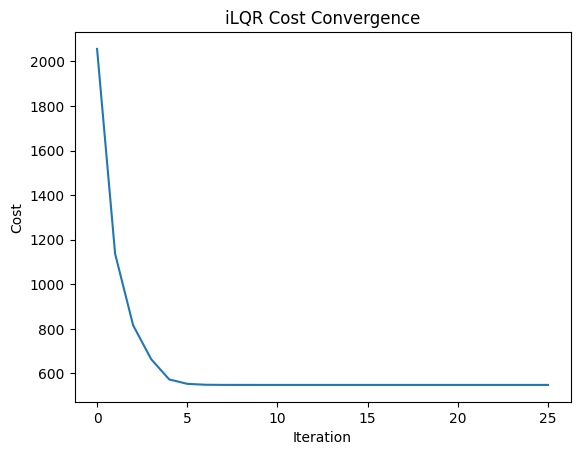

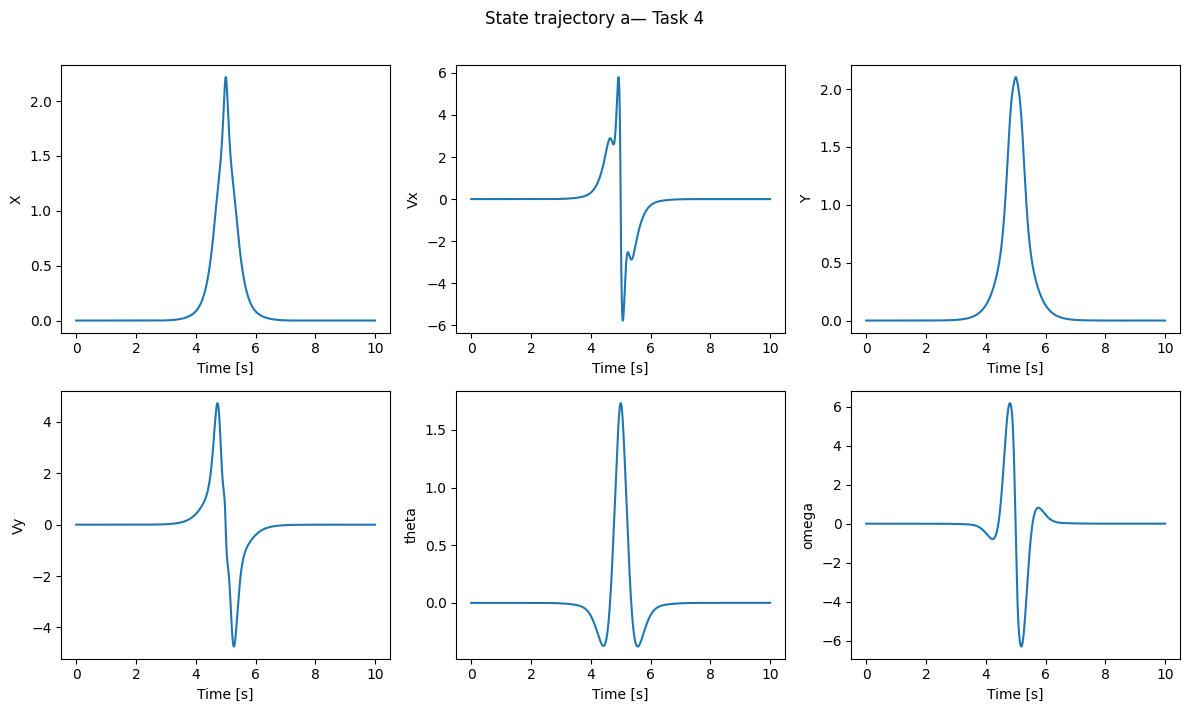

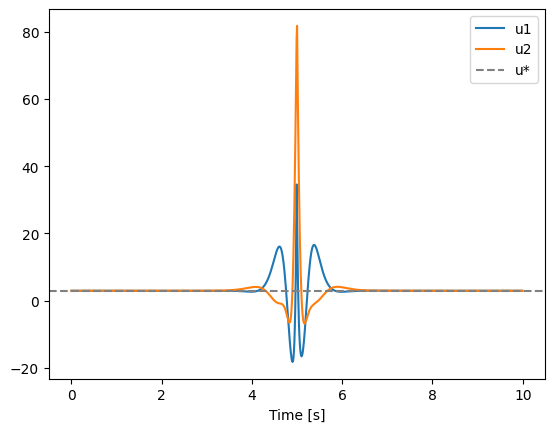

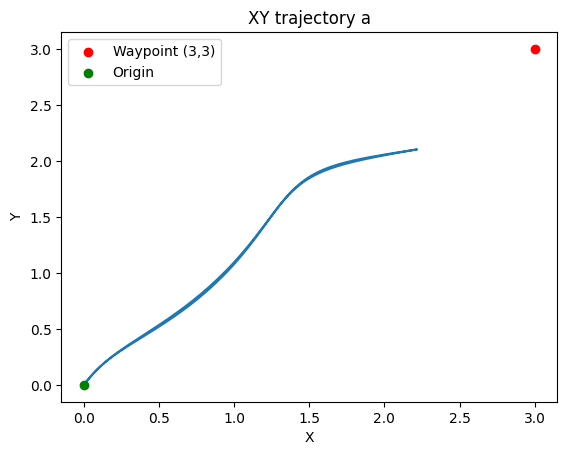

In [43]:
# Cost convergence
plt.figure()
plt.plot(cost_hist1)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('iLQR Cost Convergence')
#save_plt('Cost convergence a')

t1 = np.linspace(0, N1 * dt, N1 + 1)

# State trajectory
fig, axes = plt.subplots(2, 3, figsize=[12, 7])
labels = ['X', 'Vx', 'Y', 'Vy', 'theta', 'omega']
for k, (ax, lb) in enumerate(zip(axes.flat, labels)):
    ax.plot(t1, z_traj1[k, :])
    ax.set_ylabel(lb)
    ax.set_xlabel('Time [s]')
ax.figure.suptitle('State trajectory a— Task 4', y=1.01)
plt.tight_layout()
save_plt('State trajectory a')

# Control trajectory
plt.figure()
plt.plot(t1[:-1], u_traj1.T)
plt.axhline(u_star[0], color='gray', linestyle='--', label='u*')
plt.legend(['u1', 'u2', 'u*'])
plt.xlabel('Time [s]')
#plt.title('Control trajectory — Task 4')
save_plt('Control vs time a')

# XY trajectory
plt.figure()
plt.plot(z_traj1[0, :], z_traj1[2, :])
plt.scatter([3], [3], color='red', zorder=5, label='Waypoint (3,3)')
plt.scatter([0], [0], color='green', zorder=5, label='Origin')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('XY trajectory a')
#save_plt('XY trajectory a')

In [44]:
# Animation — Task 4
save_animate('my_animation a', quadrotor.animate_robot(z_traj1, u_traj1, pass_fps=True))

Your browser does not support the video tag.

## Task 2 — Full Flip

**Waypoints:**
- $t=5$: $[x=1.5,\; v_x=0,\; y=3,\; v_y=0,\; \theta=\pi,\; \omega=0]$ (upside-down)
- $T=10$: $[x=3,\; v_x=0,\; y=0,\; v_y=0,\; \theta=2\pi,\; \omega=0]$ (upright)

**Cost function:** same structure as Task 1 with two waypoint terms.

In [45]:
N2    = 1000
z_wp2 = np.array([1.5, 0., 3., 0., np.pi, 0.])       # waypoint at t=5: upside-down
z_T2  = np.array([3.,  0., 0., 0., 2*np.pi, 0.])      # terminal at t=10: upright flip

Q_run2 = np.diag([0.1, 0.01, 0.1, 0.01, 0.1,  0.01])
Q_wp2  = np.diag([300., 10., 300., 10., 300., 10.])
QN2    = np.diag([300., 10., 300., 10., 300., 10.])
R2     = np.eye(2) * 0.001

def compute_cost_task2(z_traj, u_traj):
    cost = 0.
    for n in range(N2):
        du = u_traj[:, n] - u_star
        dz = z_traj[:, n]
        cost += 0.5 * (dz @ Q_run2 @ dz + du @ R2 @ du)
        if n == N2 // 2:
            dz_wp = z_traj[:, n] - z_wp2
            cost += 0.5 * dz_wp @ Q_wp2 @ dz_wp
    dz_N = z_traj[:, N2] - z_T2
    cost += 0.5 * dz_N @ QN2 @ dz_N
    return cost

def get_approx_task2(z_traj, u_traj):
    l_z, l_u, l_zz, l_uu, l_uz = [], [], [], [], []
    for n in range(N2):
        Q_n = Q_run2.copy()
        grad_z = Q_run2 @ z_traj[:, n]
        if n == N2 // 2:
            Q_n   = Q_run2 + Q_wp2
            grad_z = Q_n @ z_traj[:, n] - Q_wp2 @ z_wp2
        l_z.append(grad_z)
        l_u.append(R2 @ (u_traj[:, n] - u_star))
        l_zz.append(Q_n)
        l_uu.append(R2)
        l_uz.append(np.zeros((2, 6)))
    l_z_N = QN2 @ (z_traj[:, N2] - z_T2)
    return l_z, l_u, l_zz, l_uu, l_uz, l_z_N, QN2

In [46]:
print('Running iLQR — Task 4: full flip (θ=0 → π → 2π)')
z_traj2, u_traj2, cost_hist2 = run_ilqr(z0, N2, compute_cost_task2, get_approx_task2, max_iter=30)

Running iLQR — Task 4: full flip (θ=0 → π → 2π)
Initial cost: 10439.70
  Iter   1: cost = 6109.3590  alpha = 0.2500
  Iter   2: cost = 3535.2366  alpha = 0.2500
  Iter   3: cost = 2345.8181  alpha = 0.2500
  Iter   4: cost = 2276.7506  alpha = 0.5000
  Iter   5: cost = 1454.1819  alpha = 0.5000
  Iter   6: cost = 723.7013  alpha = 0.5000
  Iter   7: cost = 285.3841  alpha = 1.0000
  Iter   8: cost = 234.6036  alpha = 1.0000
  Iter   9: cost = 221.3161  alpha = 1.0000
  Iter  10: cost = 220.9840  alpha = 1.0000
  Iter  11: cost = 220.9113  alpha = 1.0000
  Iter  12: cost = 220.8890  alpha = 1.0000
  Iter  13: cost = 220.8818  alpha = 1.0000
  Iter  14: cost = 220.8794  alpha = 1.0000
  Iter  15: cost = 220.8787  alpha = 1.0000
  Iter  16: cost = 220.8784  alpha = 1.0000
  Iter  17: cost = 220.8784  alpha = 1.0000
  Iter  18: cost = 220.8783  alpha = 1.0000
  Iter  19: cost = 220.8783  alpha = 1.0000
  Iter  20: cost = 220.8783  alpha = 1.0000
  Iter  21: cost = 220.8783  alpha = 1.0000


Text(0.5, 1.0, 'XY trajectory — Task 4 (Full Flip)')

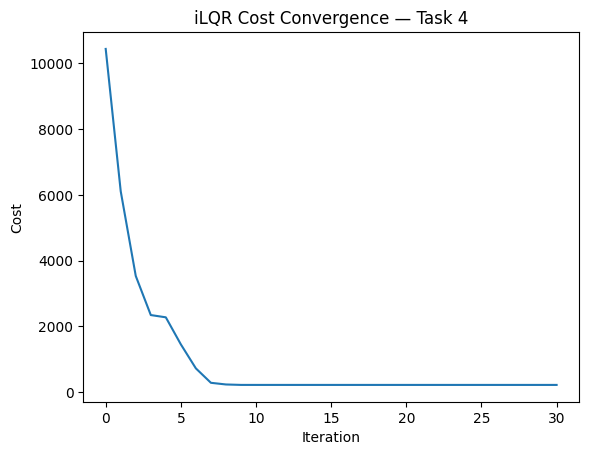

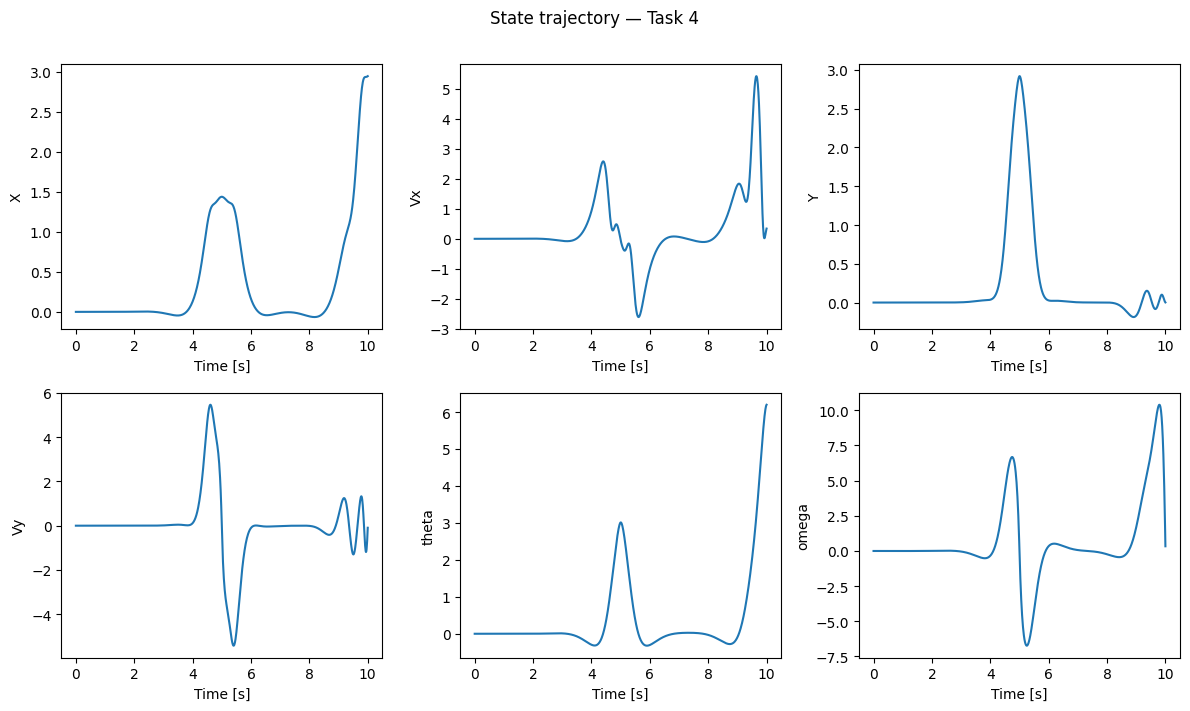

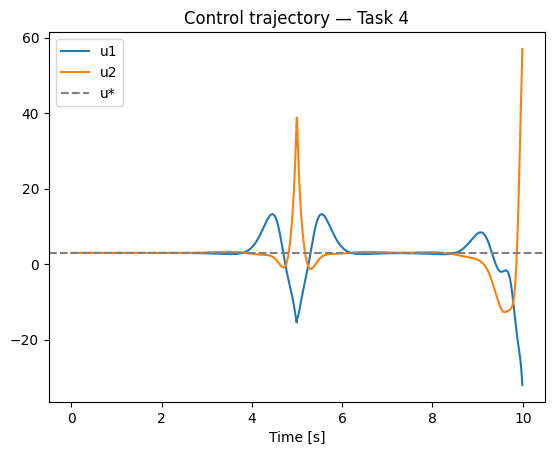

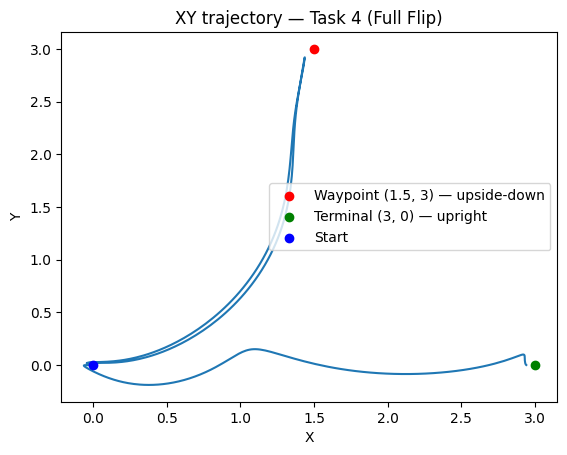

In [47]:
# Cost convergence
plt.figure()
plt.plot(cost_hist2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('iLQR Cost Convergence — Task 4')
#save_plt('Cost convergence b')

t2 = np.linspace(0, N2 * dt, N2 + 1)

# State trajectory
fig, axes = plt.subplots(2, 3, figsize=[12, 7])
labels = ['X', 'Vx', 'Y', 'Vy', 'theta', 'omega']
for k, (ax, lb) in enumerate(zip(axes.flat, labels)):
    ax.plot(t2, z_traj2[k, :])
    ax.set_ylabel(lb)
    ax.set_xlabel('Time [s]')
ax.figure.suptitle('State trajectory — Task 4', y=1.01)
plt.tight_layout()
save_plt('State trajectory b')

# Control trajectory
plt.figure()
plt.plot(t2[:-1], u_traj2.T)
plt.axhline(u_star[0], color='gray', linestyle='--', label='u*')
plt.legend(['u1', 'u2', 'u*'])
plt.xlabel('Time [s]')
plt.title('Control trajectory — Task 4')
save_plt('Control vs time b')

# XY trajectory
plt.figure()
plt.plot(z_traj2[0, :], z_traj2[2, :])
plt.scatter([1.5], [3],   color='red',    zorder=5, label='Waypoint (1.5, 3) — upside-down')
plt.scatter([3],   [0],   color='green',  zorder=5, label='Terminal (3, 0) — upright')
plt.scatter([0],   [0],   color='blue',   zorder=5, label='Start')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('XY trajectory — Task 4 (Full Flip)')
#save_plt('XY trajectory b')

In [48]:
# Animation — Task 4
save_animate('my_animation b', quadrotor.animate_robot(z_traj2, u_traj2, pass_fps=True))

Your browser does not support the video tag.